In [1]:
from skimage import feature
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import os
from pathlib import Path
import sys
from sklearn.model_selection import train_test_split, cross_val_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import accuracy_score, classification_report, average_precision_score
from sklearn.metrics import precision_recall_curve

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier as DTC
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.neighbors import KNeighborsClassifier as KNN
import xgboost as XGB


In [2]:
parent_folder = Path().resolve().parent
src_path = parent_folder / 'src'
sys.path.append(str(src_path))

from tools import get_embedding_birdnet

#env to use: clef

In [3]:
df_full = pd.read_csv("../testcase_3/selections.csv")

In [4]:
root_folder='../data/test_data_3/embedding/'
df_neg = get_embedding_birdnet(root_folder, 0)
df_neg["selec"] = df_neg["embed_name"].str.split("_").str[0].astype(int)


In [16]:
df_neg["filename"] = df_neg["embed_name"].str.split(".", n=1).str[0]

In [5]:
df_neg = df_neg.merge(
    df_full,
    on="selec",
    how="left"
)

df_neg = df_neg.dropna()

In [6]:
df_neg["date_sound"] = df_neg["sound.files"].str.split("_").str[0]

In [7]:
#df_neg.sample(3)

In [8]:
df_train = pd.read_csv("../testcase_3/selecs_positive_test_samedate.csv")

In [19]:
root_folder='../data/train_data/embedding/holderried/'
df_pos = get_embedding_birdnet(root_folder, 1)

In [20]:
df_pos["selec"] = (
    df_pos["embed_name"]
    .str.extract(r"^(\d+)")
    .astype(int)
)

df_pos = df_pos.merge(
    df_train[["selec", "sound.files", "recording.id"]],
    on="selec",
    how="left"
)

df_pos["date_sound"] = df_pos["sound.files"].str.split("_").str[0]

df_pos = df_pos.dropna() # this should remove extra "selec" columns


In [21]:
df_pos["recording.id"] = df_pos["recording.id"].astype(int)

In [22]:
df_pos.head()

,embed_name,embedding,selec,sound.files,recording.id,date_sound
0,10.birdnet.embeddings.txt,"[0.06346267, 0.0024620693, 0.8934322, 0.165529...",10,20200611_192502.WAV,11600,20200611
10,1010.birdnet.embeddings.txt,"[0.0, 0.0, 0.11430993, 0.53917336, 0.958169, 0...",1010,20200630_192502.WAV,16819,20200630
11,1011.birdnet.embeddings.txt,"[0.34395242, 0.0, 1.0031606, 0.70951825, 1.785...",1011,20200630_192502.WAV,16819,20200630
12,1012.birdnet.embeddings.txt,"[0.26066467, 0.004287084, 0.0, 0.02404368, 0.0...",1012,20200630_192502.WAV,16819,20200630
13,1013.birdnet.embeddings.txt,"[0.4468956, 0.110948585, 0.20393859, 0.8493643...",1013,20200630_192502.WAV,16819,20200630


In [12]:
df_pos['target'] = 1
df_neg['target'] = 0

In [18]:
from sklearn.model_selection import GroupKFold

# Combine and shuffle
df_combined = pd.concat([df_pos, df_neg], ignore_index=True)
df_combined = df_combined.sample(frac=1, random_state=24).reset_index(drop=True)

# Features, labels, groups
X = np.vstack(df_combined["embedding"].values)
y = df_combined["target"].values
groups = df_combined["recording.id"].values

# 5-fold grouped CV
cv = GroupKFold(n_splits=5)

# Assign fold to every sample
df_combined["fold"] = -1

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y, groups)):
    df_combined.loc[val_idx, "fold"] = fold

# Save fold information
df_combined[
    ["selec", "filename", "recording.id", "target", "fold"]
].to_csv("df_combined_testcase3.csv", index=False)

print(df_combined["fold"].value_counts().sort_index())

0    161
1    160
2    160
3    160
4    160
Name: fold, dtype: int64


SVM

In [69]:
from sklearn.svm import SVC

model = SVC(kernel="rbf", cache_size=300)

accuracies = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    groups=groups,
    scoring="accuracy"
)


ap = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    groups=groups,
    scoring="average_precision"
)

print(f"Accuracy: {accuracies.mean():.4f} ± {accuracies.std(ddof=1):.4f}")
print(f"AP: {ap.mean():.4f} ± {ap.std(ddof=1):.4f}")

Accuracy: 0.8390 ± 0.0494
AP: 0.9523 ± 0.0235


Random Forest

In [70]:
model = RFC(n_jobs = -1)

accuracies = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    groups=groups,
    scoring="accuracy"
)


ap = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    groups=groups,
    scoring="average_precision"
)

print(f"Accuracy: {accuracies.mean():.4f} ± {accuracies.std(ddof=1):.4f}")
print(f"AP: {ap.mean():.4f} ± {ap.std(ddof=1):.4f}")

Accuracy: 0.7928 ± 0.0743
AP: 0.9191 ± 0.0561


XGBOOST

In [71]:
model = XGB.XGBClassifier(objective='binary:logistic')

accuracies = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    groups=groups,
    scoring="accuracy"
)


ap = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    groups=groups,
    scoring="average_precision"
)

print(f"Accuracy: {accuracies.mean():.4f} ± {accuracies.std(ddof=1):.4f}")
print(f"AP: {ap.mean():.4f} ± {ap.std(ddof=1):.4f}")

Accuracy: 0.8053 ± 0.0545
AP: 0.9318 ± 0.0251


MODEL SAVING

In [43]:
import os
import joblib
import numpy as np

from sklearn.model_selection import GroupKFold
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, average_precision_score
from sklearn.metrics import confusion_matrix

cv = GroupKFold(n_splits=5)

accuracies = []
aps = []
confusion_matrices = []

os.makedirs("saved_models", exist_ok=True)

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups), start=1):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = SVC(kernel="rbf", cache_size=500)
    #model = RFC(n_jobs = -1)

    model.fit(X_train, y_train)

    # Save model
    joblib.dump(model, f"saved_models/svm_fold_{fold}.joblib")

    # Evaluate
    y_pred = model.predict(X_test)

    y_score = model.decision_function(X_test) # SVC

    ## RFC
    #y_score = model.predict_proba(X_test)[:, 1]

    accuracies.append(accuracy_score(y_test, y_pred))
    aps.append(average_precision_score(y_test, y_score))
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)

    np.savetxt(
        f"saved_models/svm_confusion_matrix_fold_{fold}.csv",
        cm,
        fmt="%d",
        delimiter=","
    )

print("Accuracy per fold:", np.round(accuracies, 4))
print(f"Accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies, ddof=1):.4f}")

print("AP per fold:", np.round(aps, 4))
print(f"AP: {np.mean(aps):.4f} ± {np.std(aps, ddof=1):.4f}")

Accuracy per fold: [0.7702 0.8562 0.8375 0.9062 0.825 ]
Accuracy: 0.8390 ± 0.0494
AP per fold: [0.9697 0.9633 0.9294 0.9745 0.9249]
AP: 0.9523 ± 0.0234


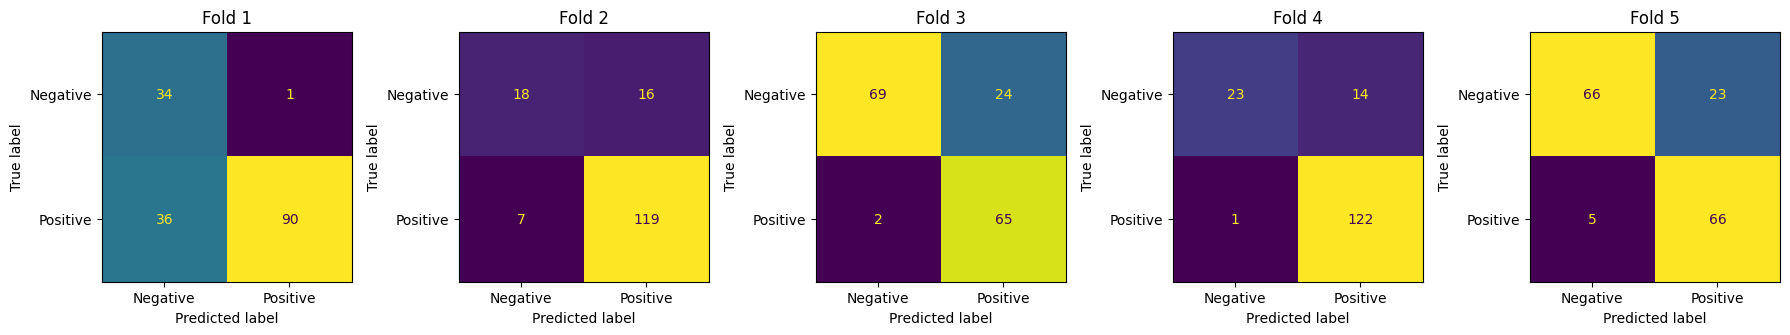

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, cm in enumerate(confusion_matrices):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Negative", "Positive"]
    )
    disp.plot(ax=axes[i], colorbar=False)
    axes[i].set_title(f"Fold {i+1}")

plt.tight_layout()
plt.savefig("./saved_models/svm_confusion_matrices_5fold.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
#plt.plot(recall, precision, marker='.')
#plt.xlabel('Recall')
#plt.ylabel('Precision')
#plt.title('Precision-Recall Curve')
#plt.show()